In [1]:
import numpy as np
import scipy
import scipy.sparse as sp
import time
import pickle

print("NumPy version:", np.__version__)
print("SciPy version:", scipy.__version__)

NumPy version: 2.1.3
SciPy version: 1.16.3


In [3]:
from google.colab import files

uploaded = files.upload()

print("Uploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving solver_handoff.pkl to solver_handoff.pkl
Uploaded files:
solver_handoff.pkl


In [4]:
with open("solver_handoff.pkl", "rb") as f:
    solver_input = pickle.load(f)

print("MILP handoff loaded successfully!")
print("Available objects:")
print(solver_input.keys())

MILP handoff loaded successfully!
Available objects:
dict_keys(['A', 'constraint_lower', 'constraint_upper', 'objective', 'variable_lower', 'variable_upper', 'variable_integrality', 'n_variables', 'n_constraints', 'nnz', 'flight_variables', 'aircraft_variables', 'crew_variables', 'aircraft_arc_variables', 'constraint_rows'])


In [5]:
A = solver_input["A"]

constraint_lower = solver_input["constraint_lower"]
constraint_upper = solver_input["constraint_upper"]

c = solver_input["objective"]

variable_lower = solver_input["variable_lower"]
variable_upper = solver_input["variable_upper"]

variable_integrality = solver_input["variable_integrality"]

print("All MILP objects extracted successfully.")

All MILP objects extracted successfully.


In [6]:
print("Matrix type:", type(A))
print("Matrix format:", A.format)
print("Matrix shape:", A.shape)
print("Number of nonzeros:", A.nnz)

Matrix type: <class 'scipy.sparse._csr.csr_matrix'>
Matrix format: csr
Matrix shape: (3443145, 472798)
Number of nonzeros: 7898666


In [7]:
print("Number of variables:", len(c))
print("Number of constraints:", A.shape[0])

print("Constraint lower:", len(constraint_lower))
print("Constraint upper:", len(constraint_upper))

print("Variable lower:", len(variable_lower))
print("Variable upper:", len(variable_upper))
print("Integrality:", len(variable_integrality))
assert A.shape[1] == len(c)
assert A.shape[0] == len(constraint_lower)
assert A.shape[0] == len(constraint_upper)

assert len(c) == len(variable_lower)
assert len(c) == len(variable_upper)
assert len(c) == len(variable_integrality)

print("\n✓ ALL DIMENSIONS MATCH")

Number of variables: 472798
Number of constraints: 3443145
Constraint lower: 3443145
Constraint upper: 3443145
Variable lower: 472798
Variable upper: 472798
Integrality: 472798

✓ ALL DIMENSIONS MATCH


In [8]:
integer_variables = np.sum(variable_integrality != 0)
continuous_variables = np.sum(variable_integrality == 0)

print("Integer/Binary variables:", integer_variables)
print("Continuous variables:", continuous_variables)

Integer/Binary variables: 472009
Continuous variables: 789


In [9]:
print("Variable lower bound range:")
print(np.min(variable_lower), "to", np.max(variable_lower))

print("\nVariable upper bound range:")
print(np.min(variable_upper), "to", np.max(variable_upper))

Variable lower bound range:
0.0 to 120.0

Variable upper bound range:
1.0 to 180.0


In [12]:
x_test = np.zeros(A.shape[1], dtype=np.float64)

start = time.perf_counter()

Ax = A @ x_test

elapsed = time.perf_counter() - start

print("Ax shape:", Ax.shape)
print("Time:", elapsed, "seconds")

Ax shape: (3443145,)
Time: 0.03191317099935986 seconds


In [13]:
y_test = np.zeros(A.shape[0], dtype=np.float64)

start = time.perf_counter()

ATy = A.T @ y_test

elapsed = time.perf_counter() - start

print("A.T @ y shape:", ATy.shape)
print("Time:", elapsed, "seconds")

A.T @ y shape: (472798,)
Time: 0.03650467400075286 seconds


In [14]:
objective_value = c @ x_test

print("Objective value:", objective_value)

Objective value: 0.0


In [15]:
def constraint_violation(Ax, lower, upper):
    lower_violation = np.maximum(lower - Ax, 0)
    upper_violation = np.maximum(Ax - upper, 0)

    max_lower = np.max(lower_violation)
    max_upper = np.max(upper_violation)

    return max(max_lower, max_upper)

In [16]:
violation = constraint_violation(
    Ax,
    constraint_lower,
    constraint_upper
)

print("Maximum constraint violation:", violation)

Maximum constraint violation: 120.0


In [17]:
def bound_violation(x, lower, upper):
    lower_violation = np.maximum(lower - x, 0)
    upper_violation = np.maximum(x - upper, 0)

    return max(
        np.max(lower_violation),
        np.max(upper_violation)
    )

In [18]:
bv = bound_violation(
    x_test,
    variable_lower,
    variable_upper
)

print("Maximum bound violation:", bv)

Maximum bound violation: 120.0


In [19]:
def integrality_violation(x, integrality):
    integer_mask = integrality != 0

    if not np.any(integer_mask):
        return 0.0

    return np.max(
        np.abs(x[integer_mask] - np.round(x[integer_mask]))
    )

In [20]:
iv = integrality_violation(
    x_test,
    variable_integrality
)

print("Maximum integrality violation:", iv)

Maximum integrality violation: 0.0


In [21]:
def check_solution(x, A, c,
                   constraint_lower,
                   constraint_upper,
                   variable_lower,
                   variable_upper,
                   variable_integrality):

    Ax = A @ x

    constraint_error = constraint_violation(
        Ax,
        constraint_lower,
        constraint_upper
    )

    bound_error = bound_violation(
        x,
        variable_lower,
        variable_upper
    )

    integer_error = integrality_violation(
        x,
        variable_integrality
    )

    objective = c @ x

    return {
        "objective": objective,
        "constraint_violation": constraint_error,
        "bound_violation": bound_error,
        "integrality_violation": integer_error
    }

In [22]:
result = check_solution(
    x_test,
    A,
    c,
    constraint_lower,
    constraint_upper,
    variable_lower,
    variable_upper,
    variable_integrality
)

print("Solution check:")
for key, value in result.items():
    print(f"{key}: {value}")

Solution check:
objective: 0.0
constraint_violation: 120.0
bound_violation: 120.0
integrality_violation: 0.0


In [35]:
import numpy as np
import scipy.sparse as sp
import time
# Small valid LP test problem
#
# Minimize:
#       3*x1 + 2*x2
#
# Subject to:
#       x1 + x2 >= 1
#       2*x1 + x2 <= 4
#
# Bounds:
#       0 <= x1 <= 10
#       0 <= x2 <= 10

A_test = sp.csr_matrix([
    [1.0, 1.0],
    [2.0, 1.0]
])

c_test = np.array([3.0, 2.0])

lower_test = np.array([1.0, -np.inf])
upper_test = np.array([np.inf, 4.0])

var_lower_test = np.array([0.0, 0.0])
var_upper_test = np.array([10.0, 10.0])

print("Test matrix:", A_test.shape)
print("Nonzeros:", A_test.nnz)
print("Objective:", c_test)

Test matrix: (2, 2)
Nonzeros: 4
Objective: [3. 2.]


In [36]:
x_test = np.zeros(2)

start = time.perf_counter()

Ax_test = A_test @ x_test

elapsed = time.perf_counter() - start

print("Ax:", Ax_test)
print("Ax shape:", Ax_test.shape)
print("Time:", elapsed, "seconds")

Ax: [0. 0.]
Ax shape: (2,)
Time: 0.00018432600063533755 seconds


In [37]:
from scipy.optimize import linprog

result = linprog(
    c_test,
    A_ub=np.array([
        [-1.0, -1.0],   # x1 + x2 >= 1
        [ 2.0,  1.0]    # 2x1 + x2 <= 4
    ]),
    b_ub=np.array([
        -1.0,
        4.0
    ]),
    bounds=[
        (0, 10),
        (0, 10)
    ],
    method="highs"
)

print("Reference solver status:", result.message)
print("Reference solution:", result.x)
print("Reference objective:", result.fun)

Reference solver status: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Reference solution: [0. 1.]
Reference objective: 2.0


In [38]:
def admm_lp_test(
    A,
    c,
    lower,
    upper,
    var_lower,
    var_upper,
    rho=1.0,
    iterations=100
):
    n = len(c)

    # Start from zero
    x = np.zeros(n)

    # Auxiliary variable
    z = A @ x

    # Dual variable
    u = np.zeros(len(z))

    objectives = []
    violations = []

    # Matrix used in x-update
    ATA = A.T @ A
    M = sp.eye(n) + rho * ATA

    # Factorization for small test problem
    from scipy.sparse.linalg import factorized
    solve_M = factorized(M.tocsc())

    for k in range(iterations):

        # x-update
        rhs = -c + rho * A.T @ (z - u)
        x = solve_M(rhs)

        # Apply variable bounds
        x = np.clip(
            x,
            var_lower,
            var_upper
        )

        # z-update: project Ax + u onto constraint bounds
        Ax = A @ x

        z = np.minimum(
            np.maximum(Ax + u, lower),
            upper
        )

        # Dual update
        u = u + Ax - z

        # Measurements
        objective = c @ x

        violation = constraint_violation(
            Ax,
            lower,
            upper
        )

        objectives.append(objective)
        violations.append(violation)

    return x, objectives, violations

In [39]:
start = time.perf_counter()

x_solution, objectives, violations = admm_lp_test(
    A_test,
    c_test,
    lower_test,
    upper_test,
    var_lower_test,
    var_upper_test,
    rho=1.0,
    iterations=100
)

elapsed = time.perf_counter() - start

print("ADMM prototype finished.")
print("Solution:", x_solution)
print("Objective:", objectives[-1])
print("Constraint violation:", violations[-1])
print("Time:", elapsed, "seconds")

ADMM prototype finished.
Solution: [0. 1.]
Objective: 2.0
Constraint violation: 0.0
Time: 0.10923481699956028 seconds


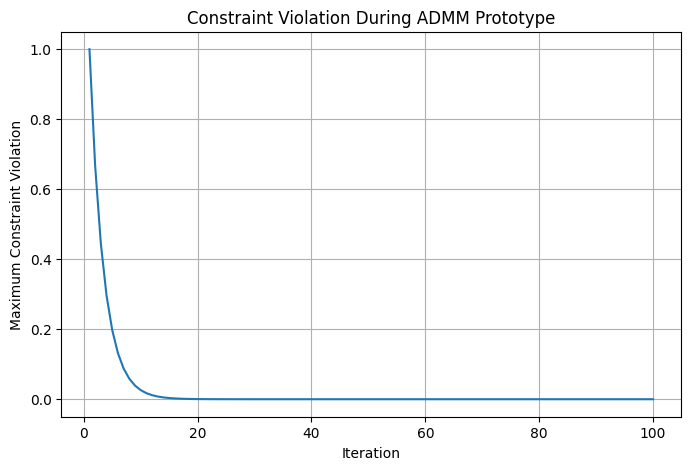

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(violations) + 1),
    violations
)

plt.xlabel("Iteration")
plt.ylabel("Maximum Constraint Violation")
plt.title("Constraint Violation During ADMM Prototype")
plt.grid(True)

plt.show()

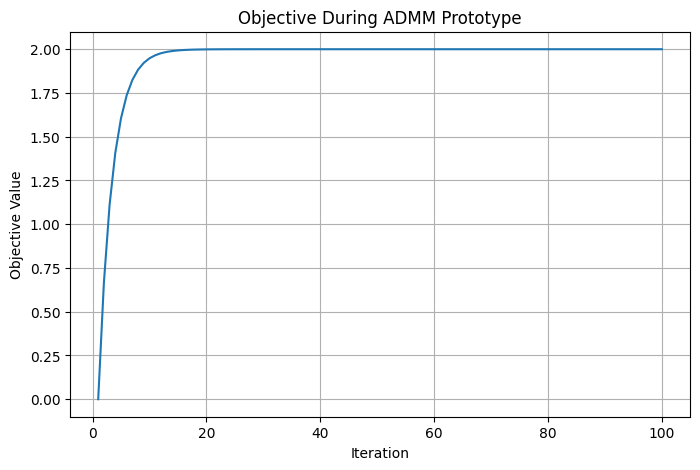

In [41]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(objectives) + 1),
    objectives
)

plt.xlabel("Iteration")
plt.ylabel("Objective Value")
plt.title("Objective During ADMM Prototype")
plt.grid(True)

plt.show()

In [42]:
print("First objective:", objectives[0])
print("Last objective:", objectives[-1])

print("First violation:", violations[0])
print("Last violation:", violations[-1])

print("\nReference objective:", result.fun)
print("ADMM objective:", objectives[-1])

First objective: 0.0
Last objective: 2.0
First violation: 1.0
Last violation: 0.0

Reference objective: 2.0
ADMM objective: 2.0


In [43]:
print("GPU handoff information")
print("------------------------")

print("A shape:", A.shape)
print("A nonzeros:", A.nnz)
print("A format:", A.format)

print("\nOperations needed:")
print("1. A @ x")
print("2. A.T @ y")
print("3. Vector operations")
print("4. Constraint residual calculation")
print("5. Objective calculation")

GPU handoff information
------------------------
A shape: (3443145, 472798)
A nonzeros: 7898666
A format: csr

Operations needed:
1. A @ x
2. A.T @ y
3. Vector operations
4. Constraint residual calculation
5. Objective calculation


In [44]:
x_bench = np.random.rand(A.shape[1])

start = time.perf_counter()

Ax_bench = A @ x_bench

cpu_time = time.perf_counter() - start

print("CPU sparse A @ x time:", cpu_time, "seconds")

CPU sparse A @ x time: 0.03457901199999469 seconds


In [45]:
solver_results = {
    "matrix_shape": A.shape,
    "matrix_nnz": A.nnz,
    "num_variables": len(c),
    "num_constraints": A.shape[0],
    "integer_variables": int(integer_variables),
    "continuous_variables": int(continuous_variables),
    "cpu_sparse_matvec_time": cpu_time
}

with open("aashna_solver_results.pkl", "wb") as f:
    pickle.dump(solver_results, f)

print("Saved: aashna_solver_results.pkl")

Saved: aashna_solver_results.pkl


In [46]:
print("=" * 50)
print("AASHNA SOLVER HANDOFF SUMMARY")
print("=" * 50)

print("Variables:", A.shape[1])
print("Constraints:", A.shape[0])
print("Nonzeros:", A.nnz)

print("Integer/Binary variables:", integer_variables)
print("Continuous variables:", continuous_variables)

print("\nMatrix format:", A.format)

print("\nCPU sparse A @ x:", cpu_time, "seconds")

print("\nFiles ready:")
print("1. presolver_milp_handoff.pkl")
print("2. aashna_solver_results.pkl")

AASHNA SOLVER HANDOFF SUMMARY
Variables: 472798
Constraints: 3443145
Nonzeros: 7898666
Integer/Binary variables: 472009
Continuous variables: 789

Matrix format: csr

CPU sparse A @ x: 0.03457901199999469 seconds

Files ready:
1. presolver_milp_handoff.pkl
2. aashna_solver_results.pkl
